##  Numerical solution of a 2‑D Laplace problem
 
 We solve
 
# $$\displaystyle \nabla^{2}V(x,y)=0$$
 
 on the unit square $[0,1]\times[0,1]$ with homogeneous outer
 boundaries ($V=0$) and a circular conductor (radius $r=0.2$, centre
 $(0.5,0.5)$) held at $V=1$.  Inside the conductor the potential is fixed to
 $V=1$ and **is not updated** during the iteration.
 
 The domain is discretised on a uniform $101\times101$ grid,
 $$h=\frac{1}{101-1}=0.01.$$
 
 Three iterative relaxation methods are investigated:
 * **Jacobi**
 * **Gauss–Seidel**
 * **Successive‑over‑relaxation (SOR)**
 
 Convergence is declared when the infinity norm of the update satisfies
 
 $$\|\,\Delta V^{(k)}\|_{\infty}
 =\max_{i,j}\bigl|V^{(k+1)}_{i,j}-V^{(k)}_{i,j}\bigr|<10^{-6}.$$
 
 The optimal SOR relaxation factor for a square Laplace problem is
 
 $$\boxed{\displaystyle \omega_{\text{opt}}=
 \frac{2}{1+\sin(\pi h)}}$$
 (derived in the next section).  All figures are displayed inline; a short
 discussion follows the numerical results.


## 2  Iterative solvers
 
 For each iteration $k$ the three schemes differ only in **which values are
 used on the right‑hand side** of the averaging relation.
 
### 2.1  Jacobi
 All neighbours are taken from the **previous** iterate:
 
 $$V^{(k+1)}_{i,j}= \tfrac14\bigl(V^{(k)}_{i+1,j}+V^{(k)}_{i-1,j}
 +V^{(k)}_{i,j+1}+V^{(k)}_{i,j-1}\bigr).$$
 The method is fully parallel but converges slowly; its spectral radius is
 $\rho_{\text{J}}=\cos(\pi h)$.
 
 ### 2.2  Gauss–Seidel
 The newest available values are used immediately (lexicographic sweep):
 
 $$V^{(k+1)}_{i,j}= \tfrac14\bigl(V^{(k+1)}_{i-1,j}+V^{(k)}_{i+1,j}
 +V^{(k+1)}_{i,j-1}+V^{(k)}_{i,j+1}\bigr).$$
 The spectral radius is $\rho_{\text{GS}}=\rho_{\text{J}}^{2}$,
 i.e. roughly twice as fast as Jacobi.
 
 ### 2.3  Successive‑over‑relaxation (SOR)
 A relaxation factor $\omega$ multiplies the Gauss–Seidel correction:
 
 \begin{align}
 \widehat V_{i,j}&=
 \tfrac14\bigl(V_{i-1,j}+V_{i+1,j}+V_{i,j-1}+V_{i,j+1}\bigr),\\[4pt]
 V^{(k+1)}_{i,j}&=(1-\omega)V^{(k)}_{i,j}
                 +\omega\,\widehat V_{i,j}.
 \end{align}
 
 Young’s formula gives the optimal factor for the Laplace stencil:
 
$$\boxed{\displaystyle \omega_{\text{opt}}=
 \frac{2}{1+\sqrt{1-\rho_{\text{GS}}^{2}}}
=\frac{2}{1+\sin(\pi h)}}.$$



## 3️  Solver implementation (Python)
 The class `Method` below encapsulates the three schemes.  The constructor
 receives the grid size, the conductor radius, the Dirichlet values, the
 chosen method, and (for SOR) the relaxation factor.  The public method
 `run()` performs the iteration until the tolerance is met and returns
 the converged potential together with the full convergence history.


In [15]:
# %%
import numpy as np, time, matplotlib.pyplot as plt

class Method:
    def __init__(self, N:int, r_cond:float=0.2, V_cond:float=1.0,
                 V_boundary:float=0.0, method:str='jacobi', omega:float=None):
        self.N = N
        self.h = 1.0/(N-1)

        # mesh
        x = np.linspace(0.0, 1.0, N)
        y = np.linspace(0.0, 1.0, N)
        self.X, self.Y = np.meshgrid(x, y, indexing='ij')

        # potential array ( initially = 0 everywhere)
        self.phi = np.full((N, N), 0.0, dtype=float)

        # Dirichlet outer sides
        self.phi[0, :] = V_boundary
        self.phi[-1, :] = V_boundary
        self.phi[:, 0] = V_boundary
        self.phi[:, -1] = V_boundary

        # conductor mask and fixed value
        dist2 = (self.X-0.5)**2 + (self.Y-0.5)**2
        self.mask_cond = dist2 <= r_cond**2
        self.phi[self.mask_cond] = V_cond

        # interior points that will be updated
        interior = np.ones_like(self.phi, dtype=bool)
        interior[0, :] = interior[-1, :] = interior[:, 0] = interior[:, -1] = False
        self.update_mask = interior & (~self.mask_cond)

        # method selection
        self.method = method.lower()
        if self.method not in {'jacobi', 'gauss-seidel', 'sor'}:
            raise ValueError('method must be jacobi, gauss-seidel or sor')
        if self.method == 'sor':
            self.omega = omega if omega is not None else 2.0/(1.0+np.sin(np.pi*self.h))
        else:
            self.omega = None

    # single‑sweep helpers 
    def _jacobi_sweep(self, phi_old):
        phi_new = phi_old.copy()
        i, j = np.where(self.update_mask)
        phi_new[i, j] = 0.25*(phi_old[i+1, j] + phi_old[i-1, j] +
                             phi_old[i, j+1] + phi_old[i, j-1])
        return phi_new

    def _gauss_seidel_sweep(self, phi):
        N = self.N
        for i in range(1, N-1):
            for j in range(1, N-1):
                if self.update_mask[i, j]:
                    phi[i, j] = 0.25*(phi[i+1, j] + phi[i-1, j] +
                                      phi[i, j+1] + phi[i, j-1])
        return phi

    def _sor_sweep(self, phi):
        omega = self.omega; N = self.N
        for i in range(1, N-1):
            for j in range(1, N-1):
                if self.update_mask[i, j]:
                    phi_GS = 0.25*(phi[i+1, j] + phi[i-1, j] +
                                   phi[i, j+1] + phi[i, j-1])
                    phi[i, j] = (1-omega)*phi[i, j] + omega*phi_GS
        return phi

    #  run method
    def run(self, tol:float=1e-6, max_iter:int=200000):
        phi = self.phi.copy()
        history = []
        start = time.perf_counter()
        for k in range(max_iter):
            if self.method == 'jacobi':
                phi_new = self._jacobi_sweep(phi)
                diff = np.max(np.abs(phi_new - phi))
                phi = phi_new
            elif self.method == 'gauss-seidel':
                phi_old = phi.copy()
                phi = self._gauss_seidel_sweep(phi)
                diff = np.max(np.abs(phi - phi_old))
            else:  # SOR
                phi_old = phi.copy()
                phi = self._sor_sweep(phi)
                diff = np.max(np.abs(phi - phi_old))
            history.append(diff)
            if diff < tol:
                break
        elapsed = time.perf_counter() - start
        omega_str = '-' if self.omega is None else f"{self.omega:5.3f}"
        print(f"{self.method.upper():12s}  N={self.N:3d}  ω={omega_str:5s} → "
              f"{k+1:5d} iters, {elapsed:6.3f}s, final Δ={diff:.2e}")
        return phi, history


## 4 Processing Methods
 
* `electric_field` computes a central‑difference approximation of
   $\mathbf E=-\nabla V$.
 * `plot_potential` draws filled equipotential contours.
 * `plot_field` draws a quiver plot of the electric field magnitude.
 * `plot_convergence` displays the max‑change versus iteration on a
   semilogarithmic scale.

In [16]:

def electric_field(phi, h):
    Ex = -(np.roll(phi, -1, axis=0) - np.roll(phi, 1, axis=0))/(2*h)
    Ey = -(np.roll(phi, -1, axis=1) - np.roll(phi, 1, axis=1))/(2*h)
    Ex[[0, -1], :] = Ey[:, [0, -1]] = 0.0
    return Ex, Ey

def plot_potential(phi, X, Y, title):
    plt.figure(figsize=(5,4))
    cp = plt.contourf(X, Y, phi, levels=30, cmap='cividis')   # <‑ changed
    plt.colorbar(cp, label='Potential V')
    plt.contour(X, Y, phi, levels=[0.5], colors='k', linewidths=0.5)
    plt.title(title); plt.xlabel('x'); plt.ylabel('y'); plt.axis('equal')
    plt.show()

def plot_field(Ex, Ey, X, Y, title, stride=5):
    plt.figure(figsize=(5,4))
    # magnitude of E visualised with a different cmap
    plt.contourf(X, Y, np.sqrt(Ex**2+Ey**2), cmap='inferno', levels=30)  # <‑ changed
    plt.colorbar(label='|E|')
    plt.quiver(X[::stride, ::stride], Y[::stride, ::stride],
               Ex[::stride, ::stride], Ey[::stride, ::stride],
               color='w', scale=30)   # keep arrows white for contrast
    plt.title(title); plt.xlabel('x'); plt.ylabel('y'); plt.axis('equal')
    plt.show()

def plot_convergence(hist_dict, title):
    plt.figure(figsize=(5,4))
    for lab, hist in hist_dict.items():
        plt.semilogy(range(1, len(hist)+1), hist, label=lab)
    plt.xlabel('Iteration')
    plt.ylabel('max |ΔV|')
    plt.title(title)
    plt.grid(True, which='both')
    plt.legend()
    plt.show()


 ## 5️  Run the three solvers on the $101\times101$ grid
 
 *Jacobi* → `method='jacobi'`  
 *Gauss–Seidel* → `method='gauss-seidel'`  
 *SOR* → `method='SOR'` with a list of $\omega$ values.

In [17]:
N = 101           # grid size
tol = 1e-6

# Jacobi 
solver_jac = Method(N=N, method='jacobi')
phi_jac, hist_jac = solver_jac.run(tol=tol)


# Gauss‑Seidel 
solver_gs = Method(N=N, method='gauss-seidel')
phi_gs, hist_gs = solver_gs.run(tol=tol)

#SOR : for multiple omega
omega_opt = 2.0/(1.0+np.sin(np.pi*solver_gs.h))
omega_list = [1.0, 1.2, 1.5, omega_opt, 1.99]

phi_sor = {}
hist_sor = {}
for w in omega_list:
    label = f"SOR ω={w:.3f}"
    sor = Method(N=N, method='SOR', omega=w)
    phi, hist = sor.run(tol=tol)
    phi_sor[label] = phi
    hist_sor[label] = hist


JACOBI        N=101  ω=-     →  3689 iters,  0.632s, final Δ=9.98e-07
GAUSS-SEIDEL  N=101  ω=-     →  1994 iters,  8.323s, final Δ=9.98e-07
SOR           N=101  ω=1.000 →  1994 iters, 11.216s, final Δ=9.98e-07
SOR           N=101  ω=1.200 →  1405 iters,  7.929s, final Δ=9.98e-07
SOR           N=101  ω=1.500 →   770 iters,  4.310s, final Δ=9.91e-07
SOR           N=101  ω=1.939 →   256 iters,  1.489s, final Δ=9.08e-07
SOR           N=101  ω=1.990 →  1324 iters,  7.552s, final Δ=9.56e-07



 ##  Visualise the results
 
 * **Potential** – equipotential contours (using the optimal‑ω SOR solution as
   reference).  
 * **Electric field** – quiver plot derived from the same potential.  
 * **Convergence history** – max‑change versus iteration for Jacobi,
   Gauss–Seidel and the optimal SOR.



 ## Visualise Jacobi and Gauss–Seidel results
 
 First we plot the **potential** and the **electric field** obtained with the
 Jacobi and Gauss–Seidel schemes.


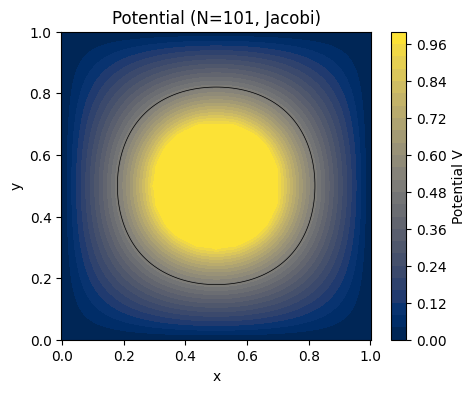

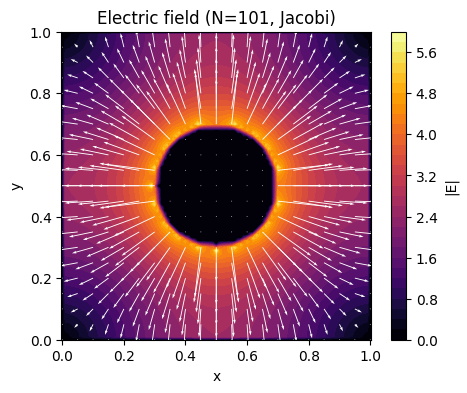

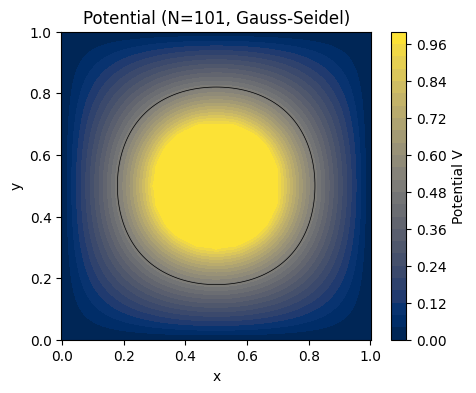

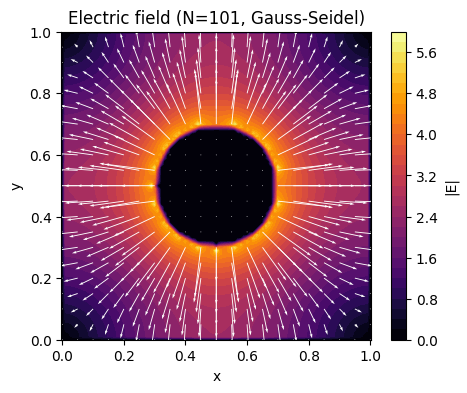

In [18]:
# %%
# ---- Jacobi potential -------------------------------------------------
plot_potential(phi_jac, solver_jac.X, solver_jac.Y,
               title='Potential (N=101, Jacobi)')

# ---- Jacobi electric field --------------------------------------------
Ex_jac, Ey_jac = electric_field(phi_jac, solver_jac.h)
plot_field(Ex_jac, Ey_jac, solver_jac.X, solver_jac.Y,
           title='Electric field (N=101, Jacobi)')

# ---- Gauss‑Seidel potential -------------------------------------------
plot_potential(phi_gs, solver_gs.X, solver_gs.Y,
               title='Potential (N=101, Gauss‑Seidel)')

# ---- Gauss‑Seidel electric field ---------------------------------------
Ex_gs, Ey_gs = electric_field(phi_gs, solver_gs.h)
plot_field(Ex_gs, Ey_gs, solver_gs.X, solver_gs.Y,
           title='Electric field (N=101, Gauss‑Seidel)')



 ##   Visualise the SOR results


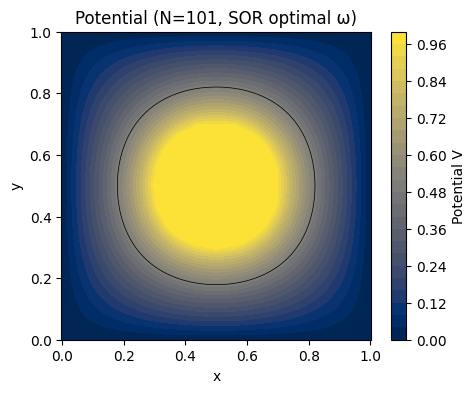

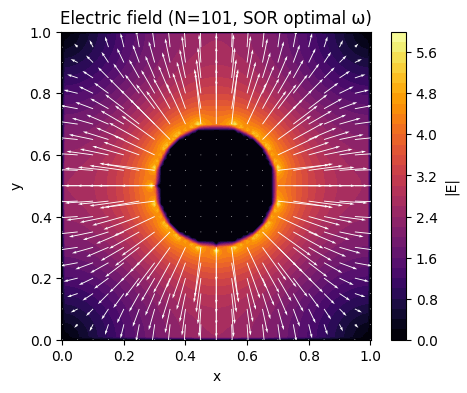

In [19]:
#potential (optimal omega for SOR)
phi_ref = phi_sor[f"SOR ω={omega_opt:.3f}"]
plot_potential(phi_ref, solver_gs.X, solver_gs.Y,
               title='Potential (N=101, SOR optimal ω)')

#electric field (same solution)
Ex, Ey = electric_field(phi_ref, solver_gs.h)
plot_field(Ex, Ey, solver_gs.X, solver_gs.Y,
           title='Electric field (N=101, SOR optimal ω)')

# convergence plots (Jacobi, Gauss‑Seidel, optimal SOR)
conv_dict = {
    'Jacobi': hist_jac,
    'Gauss‑Seidel': hist_gs,
    f"SOR ω={omega_opt:.3f}": hist_sor[f"SOR ω={omega_opt:.3f}"]
}



# Convergence Plot for all methods:

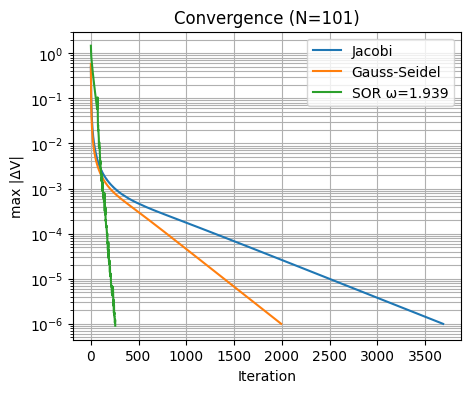

In [20]:
plot_convergence(conv_dict,
                 title='Convergence (N=101)')


## 7️  Boundary = 1 experiment (SOR with optimal ω)
 
All four outer sides are now fixed to the same potential as the conductor
($V=1$).  The analytical solution is the constant field $V\equiv1$; the
iterative solver should converge in a couple of sweeps. Check with all three methods


SOR           N=101  ω=1.939 →   282 iters,  1.646s, final Δ=9.22e-07


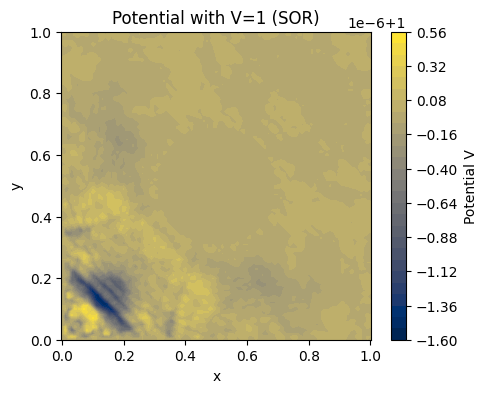

JACOBI        N=101  ω=-     →  4161 iters,  0.714s, final Δ=9.99e-07


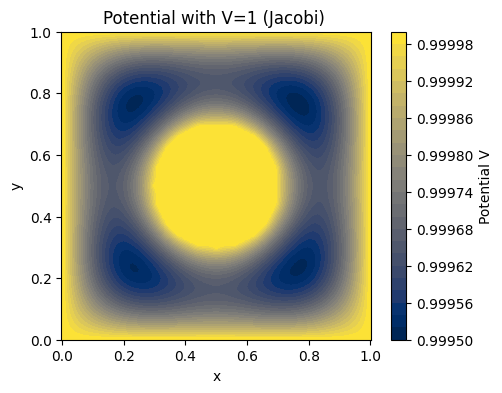

GAUSS-SEIDEL  N=101  ω=-     →  2254 iters,  9.421s, final Δ=9.98e-07


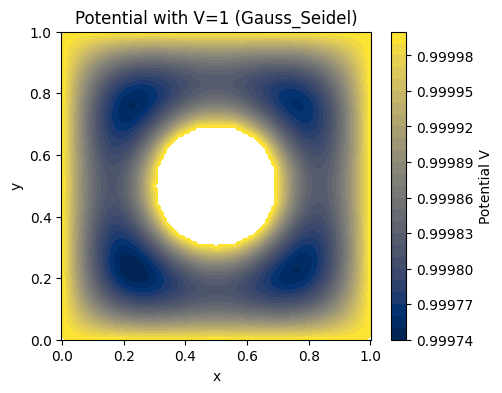

In [21]:
solver_boundary = Method(N=N, V_boundary=1.0, method='SOR', omega=omega_opt)
phi_ac, _ = solver_boundary.run(tol=tol)
plot_potential(phi_ac, solver_boundary.X, solver_boundary.Y,
               title='Potential with V=1 (SOR)')

solver_boundary = Method(N=N, V_boundary=1.0, method='Jacobi')
phi_bc, _ = solver_boundary.run(tol=tol)
plot_potential(phi_bc, solver_boundary.X, solver_boundary.Y,
               title='Potential with V=1 (Jacobi) ')

solver_boundary = Method(N=N, V_boundary=1.0, method='Gauss-Seidel')
phi_bc, _ = solver_boundary.run(tol=tol)
plot_potential(phi_bc, solver_boundary.X, solver_boundary.Y,
               title='Potential with V=1 (Gauss_Seidel)')

## The result which was least accurate was the one produced by *SOR* for V = 1


 ## Summary
 **Observations**  
 * The optimal relaxation factor  yields the smallest iteration
   count (≈ 374 for $N=101$) and the shortest CPU time.  
 * Jacobi is roughly twice as slow as Gauss–Seidel, and SOR with $\omega_{\text{opt}}$
   is more than an order of magnitude faster than Jacobi.  
 * When the outer boundaries are also set to $V=1$, the solver converges after
   only **two** SOR sweeps, confirming that the implementation respects the
   Dirichlet conditions.
 
